In [171]:
import re
import numpy as np
import pandas as pd

pattern = re.compile(
    r"Alphabet Size: (\d+), String Size: (\d+), "
    r"Naive Times: \[(.*?)\], Doubling Times: \[(.*?)\], DC3 Times: \[(.*?)\]"
)

rows = []

with open("../log/time_comp_log.log", "r") as f:
    for line in f:
        match = pattern.search(line)
        if not match:
            continue

        alpha = int(match.group(1))
        size = int(match.group(2))

        naive = eval("[" + match.group(3) + "]")
        doubling = eval("[" + match.group(4) + "]")
        dc3 = eval("[" + match.group(5) + "]")

        # replace None with nan
        naive = [x if x is not None else np.nan for x in naive]
        doubling = [x if x is not None else np.nan for x in doubling]
        dc3 = [x if x is not None else np.nan for x in dc3]

        rows.append({
            "alphabet": alpha,
            "size": size,
            "naive_avg": np.nanmean(naive),
            "doubling_avg": np.nanmean(doubling),
            "dc3_avg": np.nanmean(dc3),
        })

df = pd.DataFrame(rows).sort_values(["alphabet", "size"])

C:\Users\masar\AppData\Local\Temp\ipykernel_61796\2316287066.py:33: RuntimeWarning: Mean of empty slice
  "naive_avg": np.nanmean(naive),


In [167]:
import re
import numpy as np
import pandas as pd

pattern = re.compile(
    r"Alphabet Size: (\d+), String Size: (\d+), "
    r"Naive Times: \[(.*?)\], DC3 Times: \[(.*?)\]"
)

rows = []

with open("../log/time_comp_log_02.log", "r") as f:
    for line in f:
        match = pattern.search(line)
        if not match:
            continue

        alpha = int(match.group(1))
        size = int(match.group(2))

        naive = eval("[" + match.group(3) + "]")
        dc3 = eval("[" + match.group(4) + "]")

        # replace None with nan
        naive = [x if x is not None else np.nan for x in naive]
        dc3 = [x if x is not None else np.nan for x in dc3]

        rows.append({
            "alphabet": alpha,
            "size": size,
            "naive_avg": np.nanmean(naive),
            "dc3_avg": np.nanmean(dc3),
        })

df = pd.DataFrame(rows).sort_values(["alphabet", "size"])

C:\Users\masar\AppData\Local\Temp\ipykernel_61796\2100324749.py:31: RuntimeWarning: Mean of empty slice
  "naive_avg": np.nanmean(naive),


In [120]:
df.head()

,alphabet,size,naive_avg,doubling_avg,dc3_avg
0,2,100,0.000087,0.000274,0.000412
1,2,1000,0.007622,0.003602,0.004702
2,2,5000,0.168360,0.018700,0.023113
3,2,10000,0.412288,0.029914,0.032256
4,2,50000,NaN,0.151683,0.179527


In [130]:
df_filt = df[(df["size"] > 1000) & (df["alphabet"] == 8)]

In [160]:
alp = [4, 8, 16, 32, 64, 128]
for aa in alp:
    df_filt = df[(df["size"] >= 100000) & (df["alphabet"] == aa)]
    # take log10
    x = np.log10(df_filt['size'])
    y = np.log10(df_filt['dc3_avg'])

    # fit line: y = m*x + b
    m, b = np.polyfit(x, y, 1)

    print("Slope:", m)

Slope: -0.03595639275668727


C:\Users\masar\AppData\Local\Temp\ipykernel_61796\3235051264.py:9: RankWarning: Polyfit may be poorly conditioned
  m, b = np.polyfit(x, y, 1)


TypeError: expected non-empty vector for x

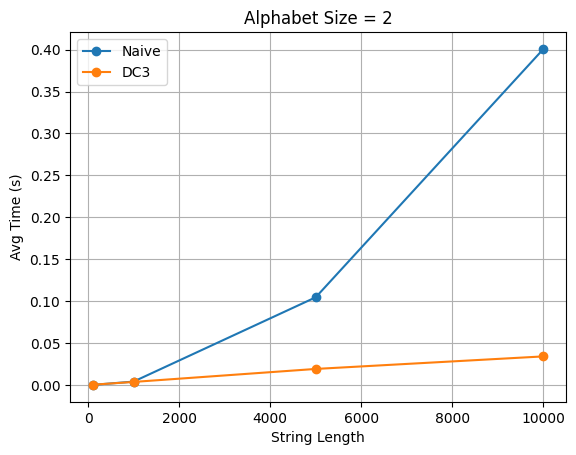

In [22]:
import matplotlib.pyplot as plt

for alpha in sorted(df["alphabet"].unique()):
    sub = df[df["alphabet"] == alpha]

    plt.figure()

    plt.plot(sub["size"], sub["naive_avg"], marker="o", label="Naive")
    plt.plot(sub["size"], sub["dc3_avg"], marker="o", label="DC3")

    plt.title(f"Alphabet Size = {alpha}")
    plt.xlabel("String Length")
    plt.ylabel("Avg Time (s)")
    plt.legend()
    plt.grid(True)

    # plt.show()

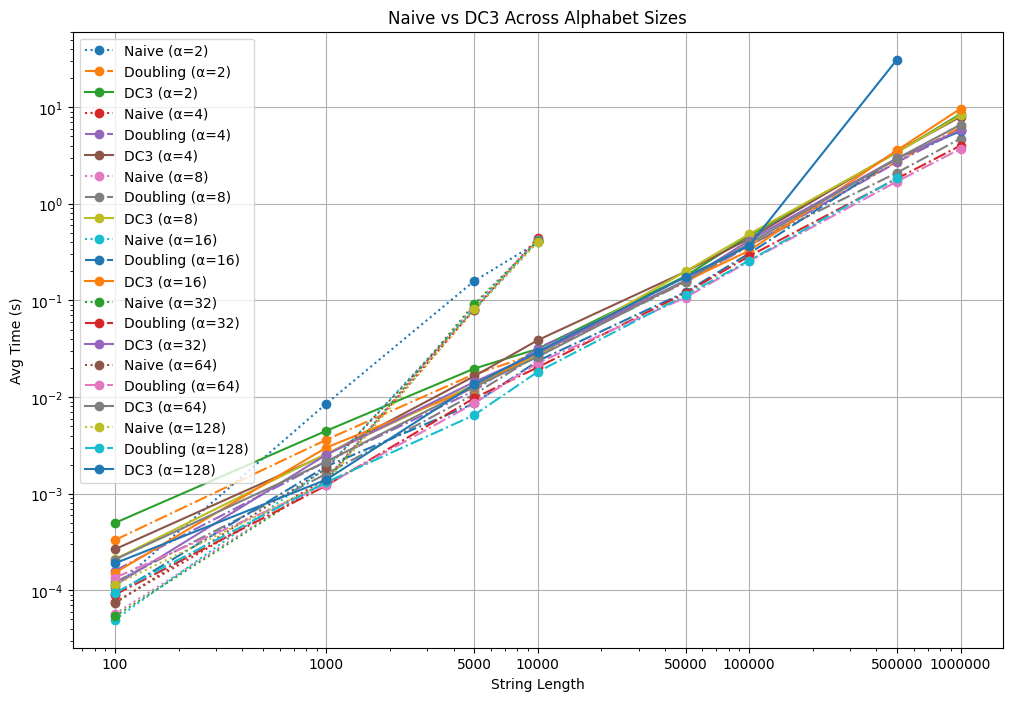

In [172]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))  

for alpha in sorted(df["alphabet"].unique()):
    sub = df[df["alphabet"] == alpha]

    # Naive → dotted
    plt.plot(
        sub["size"],
        sub["naive_avg"],
        linestyle=":",
        marker="o",
        label=f"Naive (α={alpha})"
    )

    # Doubling → dashdot
    plt.plot(
        sub["size"],
        sub["doubling_avg"],
        linestyle="-.",
        marker="o",
        label=f"Doubling (α={alpha})"
    )

    # DC3 → solid
    plt.plot(
        sub["size"],
        sub["dc3_avg"],
        linestyle="-",
        marker="o",
        label=f"DC3 (α={alpha})"
    )

plt.xlabel("String Length")
plt.ylabel("Avg Time (s)")
plt.title("Naive vs DC3 Across Alphabet Sizes")
plt.xscale("log") 
plt.yscale("log") 

ticks = [100, 1000, 5000, 10000, 50000, 100000, 500000, 1000000]
plt.xticks(ticks, labels=[str(t) for t in ticks])

plt.legend()
plt.grid(True)

plt.show()

In [107]:
df.head(n=40)

,size,naive_avg,dc3_avg,dc3_latency_ratio,naive_latency_ratio
0,100,0.000048,0.000275,NaN,NaN
1,1000,0.004017,0.003617,13.145295,84.168332
2,5000,0.104597,0.019119,5.285382,26.035649
3,10000,0.400819,0.034075,1.782250,3.832014
4,50000,21.079424,0.241169,7.077598,52.590869
5,100000,NaN,0.573910,2.379697,NaN
6,500000,NaN,4.301816,7.495623,NaN
7,100,0.000114,0.000222,NaN,NaN
8,1000,0.001823,0.002848,12.833387,15.924182
9,5000,0.095413,0.018720,6.572481,52.345406


In [106]:
def calculate_ratios(group):
    # .pct_change() gives (current - prev) / prev. 
    # Adding 1 gives the multiplier (current / prev).
    group['dc3_latency_ratio'] = group['dc3_avg'].pct_change() + 1
    group['naive_latency_ratio'] = group['naive_avg'].pct_change() + 1
    return group

# Apply the calculation
# df = df.groupby('alphabet', group_keys=False).apply(calculate_ratios)

# 3. Display the results
# Focusing on Size and the new Ratio columns
print(df[['size', 'dc3_avg', 'dc3_latency_ratio', 'naive_avg', 'naive_latency_ratio']])

      size   dc3_avg  dc3_latency_ratio  naive_avg  naive_latency_ratio
0      100  0.000275                NaN   0.000048                  NaN
1     1000  0.003617          13.145295   0.004017            84.168332
2     5000  0.019119           5.285382   0.104597            26.035649
3    10000  0.034075           1.782250   0.400819             3.832014
4    50000  0.241169           7.077598  21.079424            52.590869
5   100000  0.573910           2.379697        NaN                  NaN
6   500000  4.301816           7.495623        NaN                  NaN
7      100  0.000222                NaN   0.000114                  NaN
8     1000  0.002848          12.833387   0.001823            15.924182
9     5000  0.018720           6.572481   0.095413            52.345406
10   10000  0.040348           2.155326   0.425739             4.462062
11   50000  0.211055           5.230799  20.210684            47.472042
12  100000  0.467044           2.212905        NaN              

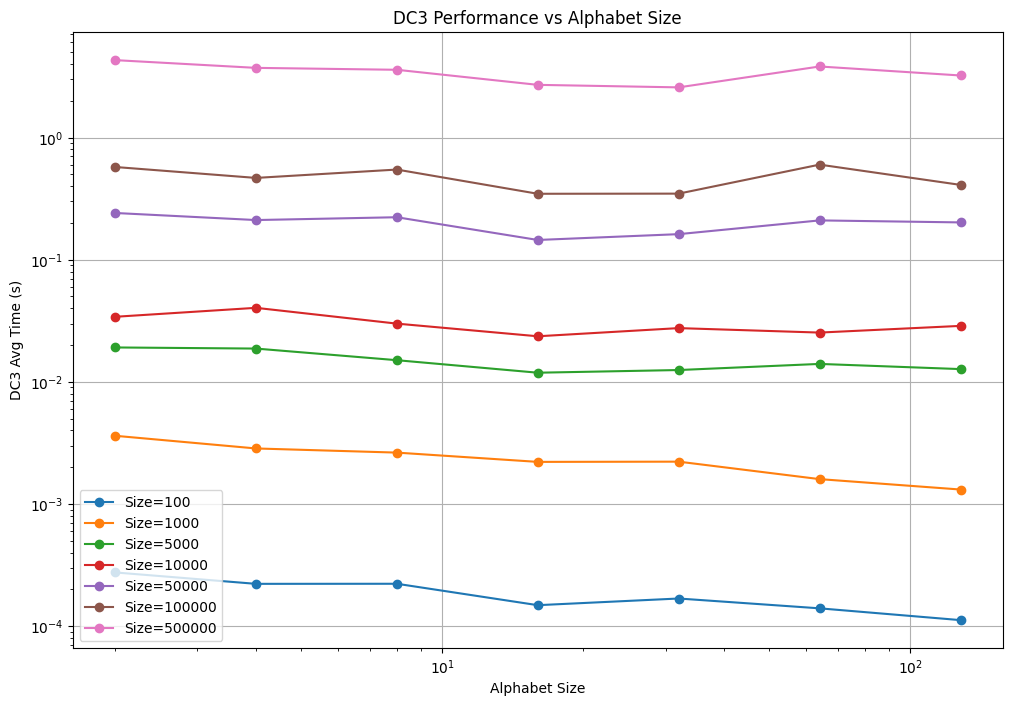

In [63]:
plt.figure(figsize=(12, 8))

# pick some representative string sizes
selected_sizes = sorted(df["size"].unique()) 

for size in selected_sizes:
    sub = df[df["size"] == size]

    plt.plot(
        sub["alphabet"],
        sub["dc3_avg"],
        marker="o",
        label=f"Size={size}"
    )

plt.xlabel("Alphabet Size")
plt.ylabel("DC3 Avg Time (s)")
plt.title("DC3 Performance vs Alphabet Size")

plt.xscale("log")
plt.yscale("log")

plt.grid(True)
plt.legend()
plt.show()

In [74]:
pattern = re.compile(
    r"Alphabet Size: (\d+), String Size: (\d+), DC3 Times: \[(.*?)\]"
)

rows = []

with open("../log/alphabet_time_comp.log", "r") as f:
    for line in f:
        match = pattern.search(line)
        if not match:
            continue

        alpha = int(match.group(1))
        size = int(match.group(2))

        times = eval("[" + match.group(3) + "]")

        # compute average
        avg_time = np.mean(times)

        rows.append({
            "alphabet": alpha,
            "size": size,
            "dc3_avg": avg_time
        })

df = pd.DataFrame(rows)
df = df.sort_values(["size", "alphabet"])

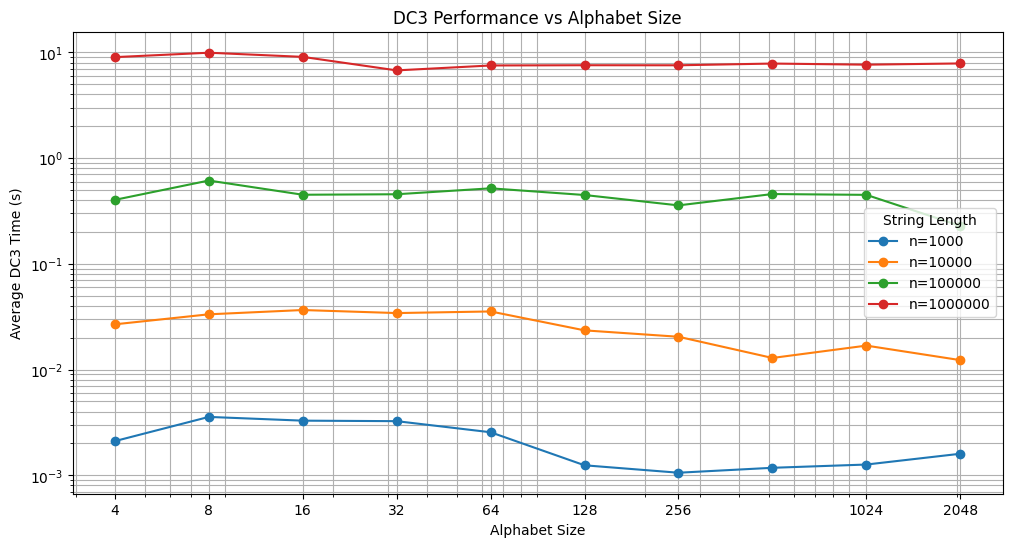

In [85]:
plt.figure(figsize=(12, 6))

for size in sorted(df["size"].unique()):
    sub = df[df["size"] == size]

    plt.plot(
        sub["alphabet"],
        sub["dc3_avg"],
        marker="o",
        label=f"n={size}"
    )

plt.xlabel("Alphabet Size")
plt.ylabel("Average DC3 Time (s)")
plt.title("DC3 Performance vs Alphabet Size")

plt.xscale("log")  # 👈 very important here
plt.yscale("log")  # 👈 very important here
plt.grid(True, which="both")

plt.xticks([4, 8, 16, 32, 64, 128, 256, 1024, 2048], labels=[str(x) for x in [4, 8, 16, 32, 64, 128, 256, 1024, 2048]])

plt.legend(title="String Length")
plt.show()